# Single Embedding Analysis

**Objective**: Đánh giá từng loại embedding riêng lẻ với 10-Fold CV

**Models**:
- BERT: PhoBERT-v2, ViSoBERT, PhoBERT-Large (Pretrained & Finetuned)
- TF-IDF (TruncatedSVD reduced)

**Evaluation**: LogisticRegression + StratifiedKFold (10 folds)

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## 1. Load Embeddings

In [2]:
ENCODED_DIR = PROJECT_ROOT / 'data' / 'encoded'

# Load labels
df = pd.read_csv(ENCODED_DIR / 'final_data_shuffled.csv')
labels = df['label'].values
print(f"Samples: {len(labels)}, Distribution: {dict(pd.Series(labels).value_counts())}")

Samples: 4736, Distribution: {0: 3929, 1: 807}


In [3]:
# Load all embeddings
embeddings = {}

bert_configs = [
    ('phobertv2', 'pretrained', 'PhoBERT-v2-Pretrained'),
    ('phobertv2', 'finetuned', 'PhoBERT-v2-Finetuned'),
    ('visobert', 'pretrained', 'ViSoBERT-Pretrained'),
    ('visobert', 'finetuned', 'ViSoBERT-Finetuned'),
    ('phobertlarge', 'pretrained', 'PhoBERT-Large-Pretrained'),
    ('phobertlarge', 'finetuned', 'PhoBERT-Large-Finetuned'),
]

for folder, suffix, name in bert_configs:
    path = ENCODED_DIR / folder / f'{suffix}_embeddings.npy'
    if path.exists():
        emb = np.load(path)
        embeddings[name] = emb
        print(f"✓ {name}: {emb.shape}")
    else:
        print(f"✗ NOT FOUND: {path}")

# TF-IDF
tfidf_path = ENCODED_DIR / 'tfidf' / 'tfidf_embeddings.npy'
if tfidf_path.exists():
    embeddings['TF-IDF'] = np.load(tfidf_path)
    print(f"✓ TF-IDF: {embeddings['TF-IDF'].shape}")

✓ PhoBERT-v2-Pretrained: (4736, 88)
✓ PhoBERT-v2-Finetuned: (4736, 68)
✓ ViSoBERT-Pretrained: (4736, 178)
✓ ViSoBERT-Finetuned: (4736, 68)
✓ PhoBERT-Large-Pretrained: (4736, 144)
✓ PhoBERT-Large-Finetuned: (4736, 24)
✓ TF-IDF: (4736, 120)


## 2. Evaluation Setup

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

def evaluate_single(X, y, name=""):
    """Evaluate single embedding with 10-Fold CV"""
    X_scaled = StandardScaler().fit_transform(X)
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    auc = cross_val_score(clf, X_scaled, y, cv=cv, scoring='roc_auc')
    f1 = cross_val_score(clf, X_scaled, y, cv=cv, scoring='f1')
    prec = cross_val_score(clf, X_scaled, y, cv=cv, scoring='precision')
    rec = cross_val_score(clf, X_scaled, y, cv=cv, scoring='recall')
    
    return {
        'name': name, 'dim': X.shape[1],
        'auc_mean': auc.mean(), 'auc_std': auc.std(),
        'f1_mean': f1.mean(), 'f1_std': f1.std(),
        'prec_mean': prec.mean(), 'prec_std': prec.std(),
        'rec_mean': rec.mean(), 'rec_std': rec.std()
    }

## 3. Evaluate All Single Embeddings

In [5]:
print("Evaluating single embeddings (10-Fold CV)...\n")

results = []
for name, emb in tqdm(embeddings.items(), desc="Evaluating"):
    r = evaluate_single(emb, labels, name)
    results.append(r)
    print(f"{name:<30}: AUC={r['auc_mean']:.4f}±{r['auc_std']:.3f}, F1={r['f1_mean']:.4f}±{r['f1_std']:.3f}")

df_results = pd.DataFrame(results)

Evaluating single embeddings (10-Fold CV)...



Evaluating:  14%|█▍        | 1/7 [00:00<00:02,  2.15it/s]

PhoBERT-v2-Pretrained         : AUC=0.9314±0.013, F1=0.6712±0.030


Evaluating:  29%|██▊       | 2/7 [00:01<00:02,  1.93it/s]

PhoBERT-v2-Finetuned          : AUC=0.9770±0.009, F1=0.8467±0.027


...

PhoBERT-Large-Pretrained      : AUC=0.8998±0.014, F1=0.6355±0.026


Evaluating:  86%|████████▌ | 6/7 [00:03<00:00,  1.90it/s]

PhoBERT-Large-Finetuned       : AUC=0.9832±0.013, F1=0.8925±0.026


Evaluating: 100%|██████████| 7/7 [00:03<00:00,  1.83it/s]

TF-IDF                        : AUC=0.8756±0.020, F1=0.5641±0.030


In [6]:
# Summary Table
print("\n" + "="*100)
print("SINGLE EMBEDDING RESULTS (10-Fold CV)")
print("="*100)
print(f"{'Model':<30} {'Dim':>6} {'AUC':>14} {'F1':>14} {'Precision':>14} {'Recall':>14}")
print("-"*100)

for _, row in df_results.iterrows():
    print(f"{row['name']:<30} {row['dim']:>6} "
          f"{row['auc_mean']:.4f}±{row['auc_std']:.3f}  "
          f"{row['f1_mean']:.4f}±{row['f1_std']:.3f}  "
          f"{row['prec_mean']:.4f}±{row['prec_std']:.3f}  "
          f"{row['rec_mean']:.4f}±{row['rec_std']:.3f}")
print("="*100)

# Highlight best
best_bert = df_results[df_results['name'] != 'TF-IDF'].loc[
    df_results[df_results['name'] != 'TF-IDF']['auc_mean'].idxmax()
]
print(f"\n★ Best BERT: {best_bert['name']} (AUC: {best_bert['auc_mean']:.4f})")
print(f"★ TF-IDF: {df_results[df_results['name'] == 'TF-IDF']['auc_mean'].values[0]:.4f}")


SINGLE EMBEDDING RESULTS (10-Fold CV)
Model                             Dim            AUC             F1      Precision         Recall
----------------------------------------------------------------------------------------------------
PhoBERT-v2-Pretrained              88 0.9314±0.013  0.6712±0.030  0.5557±0.028  0.8477±0.037
PhoBERT-v2-Finetuned               68 0.9770±0.009  0.8467±0.027  0.7876±0.030  0.9158±0.027
ViSoBERT-Pretrained               178 0.8728±0.017  0.5814±0.023  0.4636±0.019  0.7808±0.041
ViSoBERT-Finetuned                 68 0.9665±0.012  0.7904±0.023  0.7170±0.023  0.8823±0.046
PhoBERT-Large-Pretrained          144 0.8998±0.014  0.6355±0.026  0.5186±0.024  0.8217±0.039
PhoBERT-Large-Finetuned            24 0.9832±0.013  0.8925±0.026  0.8493±0.026  0.9406±0.032
TF-IDF                            120 0.8756±0.020  0.5641±0.030  0.4482±0.026  0.7622±0.045

★ Best BERT: PhoBERT-Large-Finetuned (AUC: 0.9832)
★ TF-IDF: 0.8756


## 4. Visualization

In [7]:
# Define display order
display_order = [
    'PhoBERT-v2-Pretrained', 'PhoBERT-v2-Finetuned',
    'ViSoBERT-Pretrained', 'ViSoBERT-Finetuned',
    'PhoBERT-Large-Pretrained', 'PhoBERT-Large-Finetuned',
    'TF-IDF'
]

# Get data in order
df_ordered = df_results.set_index('name').loc[display_order].reset_index()

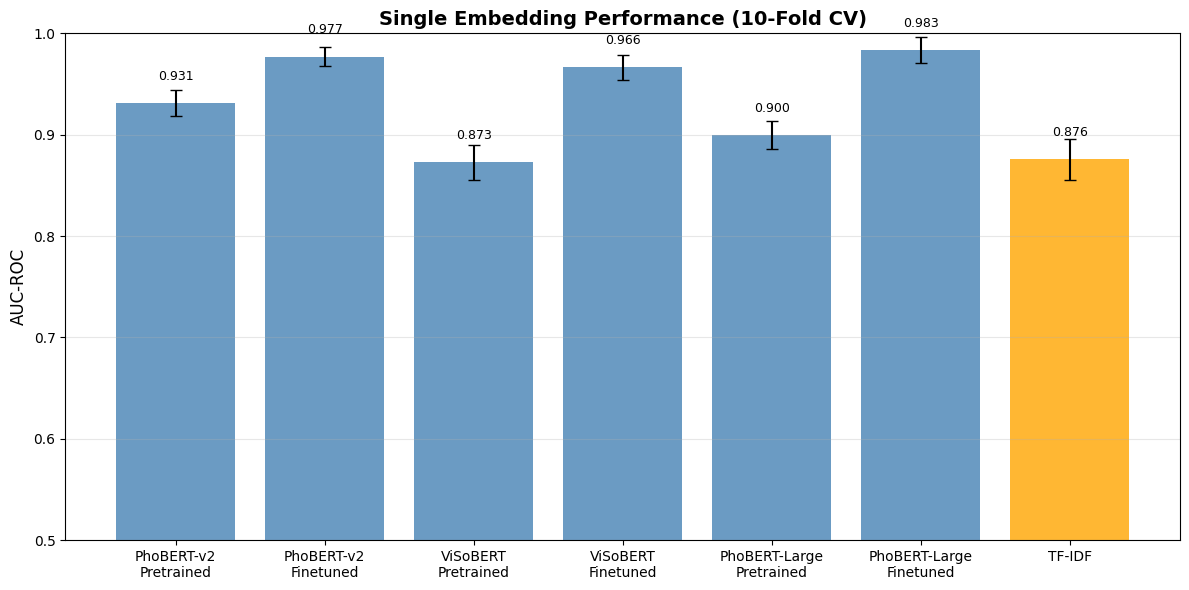

In [8]:
# Plot 1: AUC Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['steelblue']*6 + ['orange']  # BERT blue, TF-IDF orange
x_labels = ['PhoBERT-v2\nPretrained', 'PhoBERT-v2\nFinetuned',
            'ViSoBERT\nPretrained', 'ViSoBERT\nFinetuned',
            'PhoBERT-Large\nPretrained', 'PhoBERT-Large\nFinetuned',
            'TF-IDF']

bars = ax.bar(range(len(df_ordered)), df_ordered['auc_mean'], 
              yerr=df_ordered['auc_std'], capsize=4, color=colors, alpha=0.8)

ax.set_xticks(range(len(df_ordered)))
ax.set_xticklabels(x_labels, rotation=0)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Single Embedding Performance (10-Fold CV)', fontweight='bold', fontsize=14)
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, df_ordered['auc_mean'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

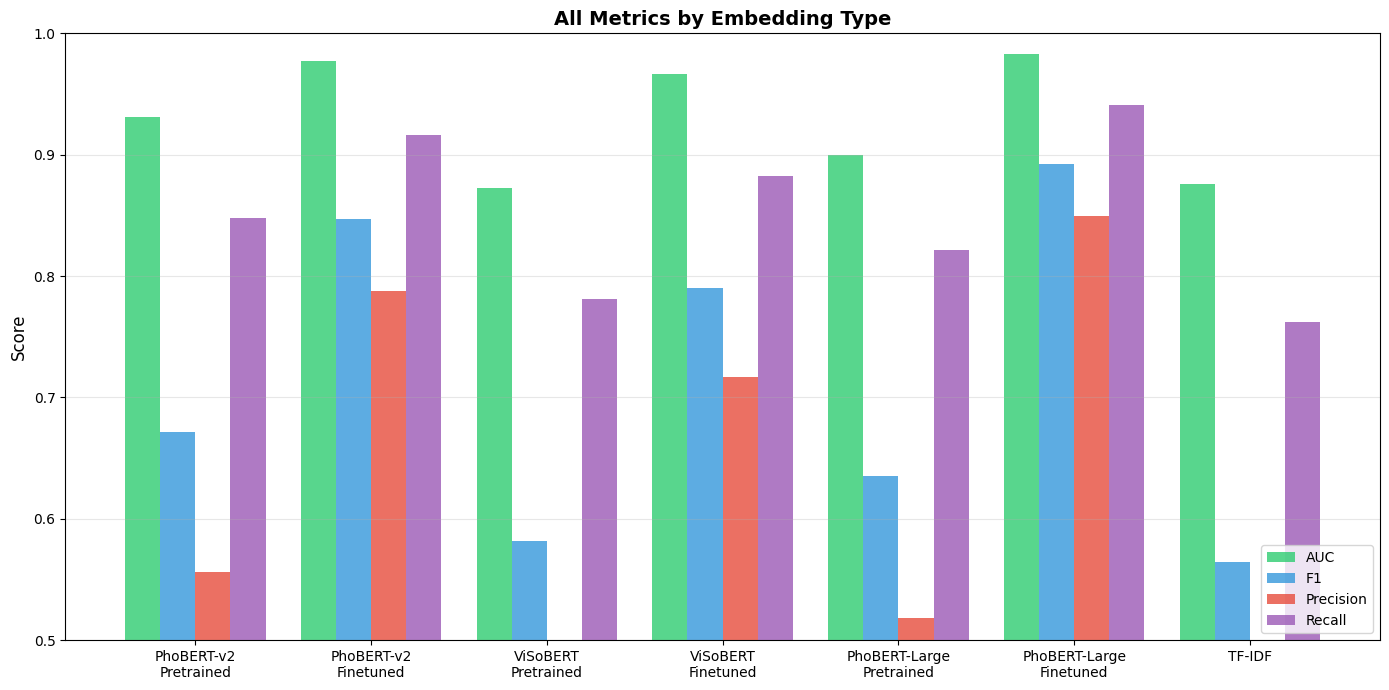

In [9]:
# Plot 2: All Metrics Grouped Bar Chart
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(df_ordered))
width = 0.2
metrics = ['auc_mean', 'f1_mean', 'prec_mean', 'rec_mean']
labels = ['AUC', 'F1', 'Precision', 'Recall']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    ax.bar(x + i*width, df_ordered[metric], width, label=label, color=color, alpha=0.8)

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(x_labels)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Metrics by Embedding Type', fontweight='bold', fontsize=14)
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

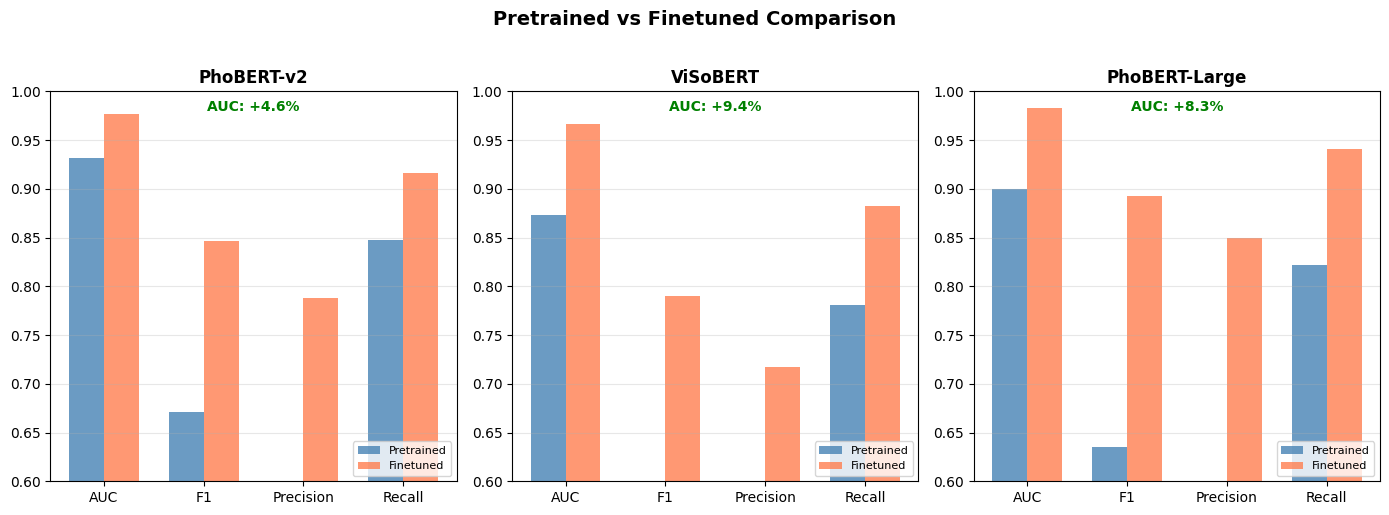

In [10]:
# Plot 3: Pretrained vs Finetuned Comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

bert_pairs = [
    ('PhoBERT-v2', 'PhoBERT-v2-Pretrained', 'PhoBERT-v2-Finetuned'),
    ('ViSoBERT', 'ViSoBERT-Pretrained', 'ViSoBERT-Finetuned'),
    ('PhoBERT-Large', 'PhoBERT-Large-Pretrained', 'PhoBERT-Large-Finetuned')
]

for ax, (title, pre_name, fine_name) in zip(axes, bert_pairs):
    pre_row = df_results[df_results['name'] == pre_name].iloc[0]
    fine_row = df_results[df_results['name'] == fine_name].iloc[0]
    
    metrics = ['AUC', 'F1', 'Precision', 'Recall']
    pre_vals = [pre_row['auc_mean'], pre_row['f1_mean'], pre_row['prec_mean'], pre_row['rec_mean']]
    fine_vals = [fine_row['auc_mean'], fine_row['f1_mean'], fine_row['prec_mean'], fine_row['rec_mean']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    ax.bar(x - width/2, pre_vals, width, label='Pretrained', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, fine_vals, width, label='Finetuned', color='coral', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0.6, 1.0)
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add improvement annotation
    auc_improve = (fine_row['auc_mean'] - pre_row['auc_mean']) * 100
    ax.text(0.5, 0.95, f'AUC: {auc_improve:+.1f}%', transform=ax.transAxes,
            ha='center', fontweight='bold', color='green' if auc_improve > 0 else 'red')

plt.suptitle('Pretrained vs Finetuned Comparison', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

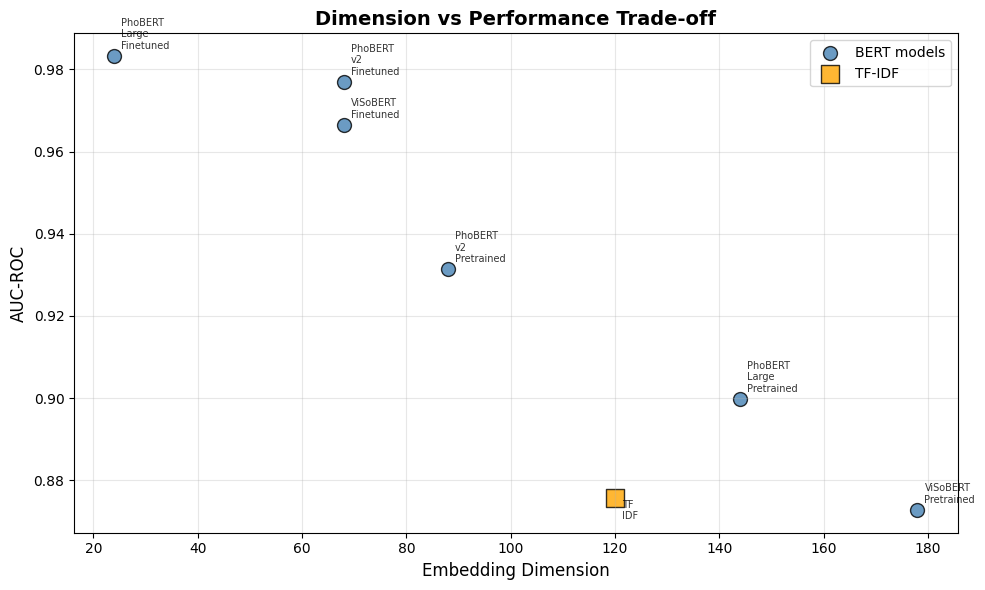

In [11]:
# Plot 4: Dimension vs Performance
fig, ax = plt.subplots(figsize=(10, 6))

# Separate BERT and TF-IDF
df_bert = df_results[df_results['name'] != 'TF-IDF']
df_tfidf = df_results[df_results['name'] == 'TF-IDF']

ax.scatter(df_bert['dim'], df_bert['auc_mean'], s=100, c='steelblue', 
           label='BERT models', alpha=0.8, edgecolors='black')
ax.scatter(df_tfidf['dim'], df_tfidf['auc_mean'], s=150, c='orange', 
           marker='s', label='TF-IDF', alpha=0.8, edgecolors='black')

# Annotate points
for _, row in df_results.iterrows():
    offset = (5, 5) if row['name'] != 'TF-IDF' else (5, -15)
    ax.annotate(row['name'].replace('-', '\n'), (row['dim'], row['auc_mean']),
                textcoords='offset points', xytext=offset, fontsize=7, alpha=0.8)

ax.set_xlabel('Embedding Dimension', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Dimension vs Performance Trade-off', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Summary & Conclusions

In [12]:
print("\n" + "="*70)
print("SINGLE EMBEDDING ANALYSIS - SUMMARY")
print("="*70)

# Best models
best_pretrained = df_results[df_results['name'].str.contains('Pretrained')].loc[
    df_results[df_results['name'].str.contains('Pretrained')]['auc_mean'].idxmax()
]
best_finetuned = df_results[df_results['name'].str.contains('Finetuned')].loc[
    df_results[df_results['name'].str.contains('Finetuned')]['auc_mean'].idxmax()
]
tfidf_result = df_results[df_results['name'] == 'TF-IDF'].iloc[0]

print(f"\n[PRETRAINED BERT]")
print(f"  Best: {best_pretrained['name']}")
print(f"  AUC:  {best_pretrained['auc_mean']:.4f} ± {best_pretrained['auc_std']:.4f}")
print(f"  Dim:  {best_pretrained['dim']}")

print(f"\n[FINETUNED BERT] (⚠️ Potential data leakage)")
print(f"  Best: {best_finetuned['name']}")
print(f"  AUC:  {best_finetuned['auc_mean']:.4f} ± {best_finetuned['auc_std']:.4f}")
print(f"  Dim:  {best_finetuned['dim']}")

print(f"\n[TF-IDF]")
print(f"  AUC:  {tfidf_result['auc_mean']:.4f} ± {tfidf_result['auc_std']:.4f}")
print(f"  Dim:  {tfidf_result['dim']}")

print("\n" + "-"*70)
print("KEY FINDINGS:")
print("-"*70)
print("1. Finetuning improves AUC by 5-10% but may have data leakage issue")
print("2. PhoBERT-v2 and PhoBERT-Large show similar performance")
print("3. PhoBERT-v2 is preferred (fewer parameters, similar results)")
print("4. TF-IDF alone performs well but below BERT models")
print("="*70)


SINGLE EMBEDDING ANALYSIS - SUMMARY

[PRETRAINED BERT]
  Best: PhoBERT-v2-Pretrained
  AUC:  0.9314 ± 0.0130
  Dim:  88

[FINETUNED BERT] (⚠️ Potential data leakage)
  Best: PhoBERT-Large-Finetuned
  AUC:  0.9832 ± 0.0127
  Dim:  24

[TF-IDF]
  AUC:  0.8756 ± 0.0200
  Dim:  120

----------------------------------------------------------------------
KEY FINDINGS:
----------------------------------------------------------------------
1. Finetuning improves AUC by 5-10% but may have data leakage issue
2. PhoBERT-v2 and PhoBERT-Large show similar performance
3. PhoBERT-v2 is preferred (fewer parameters, similar results)
4. TF-IDF alone performs well but below BERT models
